In [1]:
###############################################################################
# Cell 1: Imports & Global Settings
###############################################################################
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from scipy.cluster.hierarchy import linkage, dendrogram
import scipy.spatial.distance as sdist
import copy
import random

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)



Using device: cuda


In [2]:

###############################################################################
# Cell 2: MLP with 8 layers of 64 units each
###############################################################################
class EightLayerMLP(nn.Module):
    """
    8-layer MLP with hidden dims=64 each, final out_features=10 (CIFAR-10).
    input_dim = 3*32*32=3072
    Architecture:
      input -> [linear(64) -> BatchNorm -> ReLU] x8 -> final_layer(10)
    """
    def __init__(self, input_dim=3*32*32, num_classes=10, hidden_dim=64, num_hidden_layers=8):
        super().__init__()
        self.layers = nn.ModuleList()
        prev_dim = input_dim
        for _ in range(num_hidden_layers):
            layer = nn.Sequential(
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU()
            )
            self.layers.append(layer)
            prev_dim = hidden_dim
        self.final_layer = nn.Linear(prev_dim, num_classes)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten
        for layer in self.layers:
            x = layer(x)
        x = self.final_layer(x)
        return x

    def num_layers(self):
        return len(self.layers)

    def layer_weights(self, layer_idx):
        return self.layers[layer_idx][0].weight  # Get the Linear layer's weight

    def layer_biases(self, layer_idx):
        return self.layers[layer_idx][0].bias  # Get the Linear layer's bias

    def final_layer_weights(self):
        return self.final_layer.weight
    
    def final_layer_bias(self):
        return self.final_layer.bias
###############################################################################
# Cell 3: CIFAR-10 Data Loading
###############################################################################
def get_cifar10_dataloaders(batch_size=128, num_workers=2):
    # Add data augmentation for training
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
    ])
    
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
    ])
    
    train_dataset = CIFAR10(root='./data', train=True, download=True, transform=train_transform)
    test_dataset = CIFAR10(root='./data', train=False, download=True, transform=test_transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, test_loader
###############################################################################
# Cell 4: Helper functions to compute unconditional covariancce
###############################################################################
def get_activation(model, x, layer_idx):
    """
    Return the activation (after ReLU) of layer_idx
    """
    x = x.view(x.size(0), -1)
    for i, layer in enumerate(model.layers):
        x = layer(x)  # layer is now a Sequential module
        if i == layer_idx:
            return x
    return x


def estimate_layer_cov(model, loader, layer_idx, subset_size=512, device='cpu'):
    """
    Unconditional covariance of input to layer_idx. 
    For layer_idx=0, it's the raw input (flattened).
    """
    model.eval()
    collected = 0
    all_acts = []
    for images, _ in loader:
        images = images.to(device)
        bsz = images.shape[0]
        needed = subset_size - collected
        if needed <= 0:
            break
        if bsz > needed:
            images = images[:needed]
        if layer_idx == 0:
            # raw input
            act = images.view(images.shape[0], -1)
        else:
            act = get_activation(model, images, layer_idx-1)
        all_acts.append(act.detach())
        collected += act.size(0)
        if collected >= subset_size:
            break
    X = torch.cat(all_acts, dim=0)  # (subset_size, in_features)
    mean_ = X.mean(dim=0, keepdim=True)
    Xc = X - mean_
    cov = (Xc.t() @ Xc) / (Xc.size(0)-1)
    return cov, mean_


###############################################################################
# Cell 5: Label-Conditional Covariances
###############################################################################
class ConditionalCovAverager:
    """
    Collect a small subset of samples from each class, for each layer, 
    then compute class-wise covariance, average them with class priors.
    """
    def __init__(self, num_classes=10, subset_per_class=32):
        self.num_classes = num_classes
        self.subset_per_class = subset_per_class
    
    def collect_samples(self, model, loader, layer_idx, device='cpu'):
        """
        Return list of class-wise covariances for layer_idx,
        plus the average (weighted by p_c).
        Each Cov_c = covariance of input( or activation ) to layer_idx, restricted to class c.
        """
        model.eval()
        # We'll gather up to subset_per_class samples for each class
        class_data = [[] for _ in range(self.num_classes)]
        # We don't want to gather more than we need:
        max_needed = self.subset_per_class * self.num_classes
        collected = 0

        # pass over loader
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            bsz = images.size(0)
            # get activation feeding into layer_idx:
            if layer_idx==0:
                X = images.view(bsz, -1).detach()
            else:
                X = get_activation(model, images, layer_idx-1).detach()

            for i in range(bsz):
                c = labels[i].item()
                if len(class_data[c]) < self.subset_per_class:
                    class_data[c].append(X[i].unsqueeze(0))  # shape(1,in_feats)
                    collected += 1
            if collected>=max_needed:
                break

        # Now compute class-wise cov
        Covs = []
        weights = []
        for c in range(self.num_classes):
            if len(class_data[c])==0:
                # if no samples for class c, skip
                Covs.append(None)
                weights.append(0)
                continue
            mat = torch.cat(class_data[c], dim=0)  # (#samples_c, in_feats)
            mean_ = mat.mean(dim=0, keepdim=True)
            mat_c = mat - mean_
            cov_c = (mat_c.t() @ mat_c)/(mat_c.size(0)-1) if mat_c.size(0)>1 else torch.zeros((mat_c.size(1), mat_c.size(1)), device=device)
            Covs.append(cov_c)
            weights.append(mat.shape[0])
        
        total_samps = sum(weights)
        if total_samps<1:
            # no data
            dim_in = Covs[0].shape[0] if (Covs[0] is not None) else 64  # fallback
            return torch.eye(dim_in, device=device), Covs, weights
        # Weighted average
        cond_cov = torch.zeros_like(Covs[0]) if Covs[0] is not None else None
        for c in range(self.num_classes):
            if Covs[c] is not None:
                cond_cov += (weights[c]/total_samps)*Covs[c]
        return cond_cov, Covs, weights


###############################################################################
# Single-Node + Pairwise Metrics
###############################################################################
def compute_unconditional_RQ_MI(W, cov_in):
    """
    W shape: (out_features, in_features)
    cov_in shape: (in_features, in_features)
    returns RQ, MI each shape (out_features,)
    RQ_i = (w_i^T cov_in w_i)/(w_i^T w_i)
    MI_i ~ log(1 + w_i^T cov_in w_i)
    """
    device = W.device
    wnorm = (W*W).sum(dim=1)+1e-9
    M = W @ cov_in
    quad = (M*W).sum(dim=1)
    RQ = quad/wnorm
    MI = torch.log1p(quad)
    return RQ.cpu().numpy(), MI.cpu().numpy()

def compute_unconditional_redundancy(W, cov_in):
    """
    redundancy(i,j) ~ (w_i^T cov_in w_j)/ sqrt((w_i^T w_i)*(w_j^T w_j))
    or we do normalizing by w_i^T cov_in w_i?
    We'll do the simpler version:
       M = W cov_in W^T
       denom = sqrt(diag(M)* diag(M).T)
       R = M/denom
    """
    device = W.device
    M = W @ cov_in @ W.t()  # shape (out_feats, out_feats)
    diag = torch.diag(M)
    denom = torch.sqrt(diag.unsqueeze(1)*diag.unsqueeze(0)+1e-9)
    R = M/(denom+1e-9)
    return R.cpu().numpy()

def compute_conditional_RQ_MI(W, Covs, weights):
    """
    W shape: (out_features, in_features)
    Covs: list of class-specific covariance, each shape (in_features, in_features), or None
    weights: how many samples in each class
    returns cond_RQ, cond_MI for each neuron (numpy arrays)
    cond_RQ_i = sum_c p_c * [ (w_i^T Cov_c w_i)/(w_i^T w_i ) ]
    cond_MI_i = sum_c p_c * log(1+ w_i^T Cov_c w_i )
    """
    device = W.device
    out_feats = W.size(0)
    total = sum(weights)
    if total<1:
        # fallback
        return np.zeros(out_feats), np.zeros(out_feats)
    wnorm = (W*W).sum(dim=1)+1e-9  # shape (out_feats,)

    cond_RQ_vals = torch.zeros(out_feats, device=device)
    cond_MI_vals = torch.zeros(out_feats, device=device)
    for c, cov_c in enumerate(Covs):
        if cov_c is None or weights[c]<1:
            continue
        pc = weights[c]/total
        M = W @ cov_c  # shape (out_feats, in_feats)
        quad = (M*W).sum(dim=1)  # shape (out_feats,)
        cond_RQ_vals += pc*(quad/wnorm)
        cond_MI_vals += pc*torch.log1p(quad)
    return cond_RQ_vals.cpu().numpy(), cond_MI_vals.cpu().numpy()

def compute_conditional_redundancy(W, Covs, weights):
    """
    Computes the conditional redundancy matrix based on class-specific covariances.
    
    W shape: (out_features, in_features)
    Covs: list of class-specific covariance matrices, each (in_features, in_features) or None
    weights: number of samples in each class
    
    Returns: conditional redundancy matrix (numpy array)
    cond_R(i,j) = sum_c p_c * [(w_i^T Cov_c w_j) / sqrt((w_i^T Cov_c w_i)*(w_j^T Cov_c w_j))]
    """
    device = W.device
    out_feats = W.size(0)
    total = sum(weights)
    
    if total < 1:
        # Fallback: return zeros
        return np.zeros((out_feats, out_feats))
    
    # Initialize conditional redundancy matrix
    cond_R = torch.zeros((out_feats, out_feats), device=device)
    
    # For each class
    for c, cov_c in enumerate(Covs):
        if cov_c is None or weights[c] < 1:
            continue
        
        pc = weights[c] / total
        
        # Compute M = W Cov_c W^T
        M = W @ cov_c @ W.t()  # shape (out_feats, out_feats)
        
        # Get diagonal elements for normalization
        diag = torch.diag(M)
        
        # Compute denominator: sqrt(diag(i) * diag(j))
        denom = torch.sqrt(torch.outer(diag, diag) + 1e-9)
        
        # Compute normalized redundancy
        R_c = M / (denom + 1e-9)
        
        # Accumulate weighted by class probability
        cond_R += pc * R_c
    
    return cond_R.cpu().numpy()



In [3]:

###############################################################################
# Cell 6: Training + collecting all metrics (unconditional + conditional)
###############################################################################
def train_and_collect_all_metrics(model, train_loader, test_loader, num_epochs=30, device='cuda'):
    """
    Train the model and collect both unconditional and conditional metrics at each epoch.
    
    Returns:
    - all_metrics: dict mapping epoch -> layer_idx -> metrics
    """
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3, verbose=True)
    criterion = nn.CrossEntropyLoss()
    
    # Create conditional covariance calculator
    cond_cov = ConditionalCovAverager(num_classes=10, subset_per_class=32)
    
    # Dictionary to store metrics
    all_metrics = {}
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_loss = running_loss / total
        train_acc = 100.0 * correct / total
        
        # Evaluation phase
        model.eval()
        test_correct = 0
        test_total = 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()
        
        test_acc = 100.0 * test_correct / test_total
        
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%")
        
        # Compute metrics for each layer
        epoch_metrics = {}
        
        for layer_idx in range(model.num_layers()):
            # Get layer weights
            W = model.layer_weights(layer_idx).detach()
            
            # Unconditional covariance
            cov_in, _ = estimate_layer_cov(model, train_loader, layer_idx, subset_size=256, device=device)
            
            # Unconditional metrics
            RQ_vals, MI_vals = compute_unconditional_RQ_MI(W, cov_in)
            redund_mat = compute_unconditional_redundancy(W, cov_in)
            
            # Conditional covariance
            cond_cov_avg, class_covs, class_weights = cond_cov.collect_samples(
                model, train_loader, layer_idx, device=device)
            
            # Conditional metrics
            cRQ_vals, cMI_vals = compute_conditional_RQ_MI(W, class_covs, class_weights)
            cRedund_mat = compute_conditional_redundancy(W, class_covs, class_weights)
            
            # Store all metrics
            epoch_metrics[layer_idx] = {
                'RQ': RQ_vals,
                'MI': MI_vals,
                'redund': redund_mat,
                'cRQ': cRQ_vals,
                'cMI': cMI_vals,
                'cRedund': cRedund_mat
            }
        
        all_metrics[epoch] = epoch_metrics
        
        # Update learning rate
        scheduler.step(train_loss)
    
    return all_metrics



###############################################################################
# Cell 7: Some plotting
###############################################################################
def plot_mean_metrics_vs_epoch(all_metrics, metric_list=['RQ', 'MI', 'cRQ', 'cMI', 'redund', 'cRedund']):
    """
    Plot mean value of each metric across layers and neurons for each epoch.
    
    Parameters:
    - all_metrics: Dictionary containing metrics for each epoch and layer
    - metric_list: List of metrics to plot
    """
    epochs = sorted(list(all_metrics.keys()))
    
    # Initialize dictionaries to store mean values per epoch
    mean_values = {metric: [] for metric in metric_list}
    
    for epoch in epochs:
        # For each metric, compute mean across all layers and neurons
        for metric in metric_list:
            epoch_mean = []
            
            for layer in all_metrics[epoch]:
                if metric in ['redund', 'cRedund']:
                    # For redundancy, compute mean of off-diagonal elements
                    mat = all_metrics[epoch][layer][metric]
                    n = mat.shape[0]
                    if n > 1:
                        # Create mask for off-diagonal elements
                        mask = np.ones((n, n), dtype=bool)
                        np.fill_diagonal(mask, False)
                        # Compute mean of off-diagonal elements
                        layer_mean = np.mean(mat[mask])
                    else:
                        layer_mean = 0
                else:
                    # For other metrics, compute mean of all neurons
                    layer_mean = np.mean(all_metrics[epoch][layer][metric])
                
                epoch_mean.append(layer_mean)
            
            # Average across layers
            if epoch_mean:
                mean_values[metric].append(np.mean(epoch_mean))
            else:
                mean_values[metric].append(0)
    
    # Create the plot
    plt.figure(figsize=(12, 8))
    
    for metric in metric_list:
        plt.plot(epochs, mean_values[metric], marker='o', label=metric)
    
    plt.title('Mean Metric Values vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_metrics_by_layer(all_metrics, epoch=-1):
    """
    Plot the mean value of each metric for each layer at a given epoch.
    
    Parameters:
    - all_metrics: Dictionary of metrics for each epoch and layer
    - epoch: Which epoch to use (default: -1, meaning the last epoch)
    """
    # Get the specified epoch
    epochs = sorted(list(all_metrics.keys()))
    if epoch == -1:
        epoch = epochs[-1]
    elif epoch not in epochs:
        print(f"Epoch {epoch} not found. Using last epoch {epochs[-1]} instead.")
        epoch = epochs[-1]
    
    # Get metrics for the chosen epoch
    metrics_data = all_metrics[epoch]
    
    # Get list of layers
    layers = sorted(metrics_data.keys())
    sample_layer = layers[0]
    available_metrics = list(metrics_data[sample_layer].keys())
    print(f"Available metrics: {available_metrics}")
    
    # Create a figure with subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    # Metrics to plot - use the correct names as in your data
    metrics_to_plot = ['RQ', 'MI', 'redund', 'cRQ', 'cMI', 'cRedund']
    
    # Plot for each metric
    for i, metric_name in enumerate(metrics_to_plot):
        if i >= len(axes):
            continue
            
        if metric_name not in available_metrics:
            axes[i].text(0.5, 0.5, f"Metric '{metric_name}' not available", 
                        horizontalalignment='center', verticalalignment='center',
                        transform=axes[i].transAxes)
            axes[i].set_title(f'{metric_name} (Not Available)')
            continue
        
        layer_means = []
        
        for layer in layers:
            if metric_name in ['redund', 'cRedund']:
                # For redundancy matrices, compute mean of off-diagonal elements
                redund_mat = metrics_data[layer][metric_name]
                n = redund_mat.shape[0]
                
                # Create mask for off-diagonal elements
                mask = np.ones((n, n), dtype=bool)
                np.fill_diagonal(mask, False)
                
                # Compute mean of off-diagonal elements
                layer_mean = np.mean(redund_mat[mask])
                
            else:
                # For other metrics, compute mean across all neurons
                values = metrics_data[layer][metric_name]
                layer_mean = np.mean(values)
            
            layer_means.append(layer_mean)
        
        # Plot the means vs. layer number
        axes[i].plot(layers, layer_means, marker='o', linewidth=2)
        axes[i].set_title(f'Mean {metric_name} by Layer')
        axes[i].set_xlabel('Layer')
        axes[i].set_ylabel(f'Mean {metric_name}')
        axes[i].grid(True, linestyle='--', alpha=0.7)
    
    # Add a title for the last unused subplot or hide it
    for i in range(len(metrics_to_plot), len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle(f'Mean Metrics by Layer (Epoch {epoch})', fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.show()
    
        
def plot_metric_correlations(all_metrics, epoch=-1):
    """
    Create scatter plots of RQ vs MI and conditional RQ vs conditional MI for each layer
    at the end of training.
    
    Parameters:
    - all_metrics: Dictionary containing metrics for each epoch and layer
    - epoch: Which epoch to use (default: -1, meaning the last epoch)
    """
    # Get the specified epoch (default: last epoch)
    epochs = sorted(list(all_metrics.keys()))
    if epoch == -1:
        epoch = epochs[-1]
    elif epoch not in epochs:
        print(f"Epoch {epoch} not found. Using last epoch {epochs[-1]} instead.")
        epoch = epochs[-1]
    
    # Get the metrics for the chosen epoch
    metrics_data = all_metrics[epoch]
    
    # Get list of layers
    layers = sorted(metrics_data.keys())
    n_layers = len(layers)
    
    # Check available metrics in the first layer
    sample_layer = layers[0]
    available_metrics = list(metrics_data[sample_layer].keys())
    print(f"Available metrics: {available_metrics}")
    
    # Create a figure with subplots - one row per layer, two columns for different metric pairs
    fig, axes = plt.subplots(n_layers, 2, figsize=(14, 5 * n_layers))
    
    # Handle the case of single layer (need to reshape axes)
    if n_layers == 1:
        axes = np.expand_dims(axes, axis=0)
    
    # Plot for each layer
    for i, layer in enumerate(layers):
        layer_metrics = metrics_data[layer]
        
        # First column: RQ vs MI
        if 'RQ' in available_metrics and 'MI' in available_metrics:
            rq_values = layer_metrics['RQ']
            mi_values = layer_metrics['MI']
            
            # Plot scatter of RQ vs MI
            axes[i, 0].scatter(rq_values, mi_values, alpha=0.7)
            axes[i, 0].set_xlabel('RQ')
            axes[i, 0].set_ylabel('MI')
            axes[i, 0].set_title(f'Layer {layer}: RQ vs MI')
            
            # Add correlation coefficient
            corr = np.corrcoef(rq_values, mi_values)[0, 1]
            axes[i, 0].annotate(f'Correlation: {corr:.3f}', 
                               xy=(0.05, 0.95), 
                               xycoords='axes fraction', 
                               fontsize=10,
                               ha='left', va='top')
            axes[i, 0].grid(True, linestyle='--', alpha=0.5)
        else:
            axes[i, 0].text(0.5, 0.5, "RQ or MI metrics not available",
                          horizontalalignment='center', verticalalignment='center',
                          transform=axes[i, 0].transAxes)
        
        # Second column: dRQ vs grad (as proxies for conditional metrics)
        if 'dRQ' in available_metrics and 'grad' in available_metrics:
            drq_values = layer_metrics['dRQ']
            grad_values = layer_metrics['grad']
            
            # Plot scatter of dRQ vs grad (as conditional metrics)
            axes[i, 1].scatter(drq_values, grad_values, alpha=0.7, color='orange')
            axes[i, 1].set_xlabel('dRQ (Conditional RQ)')
            axes[i, 1].set_ylabel('Gradient Norm (Conditional MI proxy)')
            axes[i, 1].set_title(f'Layer {layer}: dRQ vs Gradient Norm')
            
            # Add correlation coefficient
            corr = np.corrcoef(drq_values, grad_values)[0, 1]
            axes[i, 1].annotate(f'Correlation: {corr:.3f}', 
                               xy=(0.05, 0.95), 
                               xycoords='axes fraction', 
                               fontsize=10,
                               ha='left', va='top')
            axes[i, 1].grid(True, linestyle='--', alpha=0.5)
        else:
            axes[i, 1].text(0.5, 0.5, "dRQ or grad metrics not available",
                          horizontalalignment='center', verticalalignment='center',
                          transform=axes[i, 1].transAxes)
    
    plt.suptitle(f'Metric Correlations by Layer (Epoch {epoch})', fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()
    
def plot_individual_metrics_vs_epoch(all_metrics, metric_list=['RQ', 'MI', 'cRQ', 'cMI', 'redund', 'cRedund']):
    """
    Create a separate plot for each metric showing its mean value across epochs.
    
    Parameters:
    - all_metrics: Dictionary containing metrics for each epoch and layer
    - metric_list: List of metrics to plot
    """
    epochs = sorted(list(all_metrics.keys()))
    
    # Check which metrics are actually available
    sample_layer = list(all_metrics[epochs[0]].keys())[0]
    available_metrics = list(all_metrics[epochs[0]][sample_layer].keys())
    print(f"Available metrics: {available_metrics}")
    
    # Filter metric_list to only include available metrics
    valid_metrics = [m for m in metric_list if m in available_metrics]
    
    # Create a separate plot for each metric
    for metric in valid_metrics:
        # Initialize data for this metric
        mean_values = []
        
        for epoch in epochs:
            # For each layer, compute the mean
            layer_means = []
            
            for layer in all_metrics[epoch]:
                if metric in ['redund', 'cRedund']:
                    # For redundancy, compute mean of off-diagonal elements
                    mat = all_metrics[epoch][layer][metric]
                    n = mat.shape[0]
                    
                    # Create mask for off-diagonal elements
                    mask = np.ones((n, n), dtype=bool)
                    np.fill_diagonal(mask, False)
                    
                    # Compute mean of off-diagonal elements
                    if n > 1:
                        layer_mean = np.mean(mat[mask])
                    else:
                        layer_mean = 0
                else:
                    # For other metrics, compute mean across all neurons
                    layer_mean = np.mean(all_metrics[epoch][layer][metric])
                
                layer_means.append(layer_mean)
            
            # Average across all layers
            if layer_means:
                mean_values.append(np.mean(layer_means))
            else:
                mean_values.append(0)
        
        # Create individual plot for this metric
        plt.figure(figsize=(10, 6))
        plt.plot(epochs, mean_values, marker='o', linewidth=2, color='royalblue')
        
        # Add title and labels
        plt.title(f'Mean {metric} Over Training Epochs', fontsize=14)
        plt.xlabel('Epoch', fontsize=12)
        plt.ylabel(f'Mean {metric} Value', fontsize=12)
        
        # Add grid and formatting
        plt.grid(True, linestyle='--', alpha=0.7)
        
        # Add annotations - first and last epoch values
        if len(mean_values) > 0:
            plt.annotate(f"{mean_values[0]:.4f}", 
                        xy=(epochs[0], mean_values[0]),
                        xytext=(5, 5),
                        textcoords='offset points',
                        ha='center')
            
            plt.annotate(f"{mean_values[-1]:.4f}", 
                        xy=(epochs[-1], mean_values[-1]),
                        xytext=(5, 5),
                        textcoords='offset points',
                        ha='center')
        
        # Show plot
        plt.tight_layout()
        plt.show()
        
    # Optionally create a summary plot with all metrics normalized
    plt.figure(figsize=(12, 8))
    
    # Normalize each metric for fair comparison
    for metric in valid_metrics:
        mean_values = []
        
        for epoch in epochs:
            layer_means = []
            
            for layer in all_metrics[epoch]:
                if metric in ['redund', 'cRedund']:
                    mat = all_metrics[epoch][layer][metric]
                    n = mat.shape[0]
                    mask = np.ones((n, n), dtype=bool)
                    np.fill_diagonal(mask, False)
                    if n > 1:
                        layer_mean = np.mean(mat[mask])
                    else:
                        layer_mean = 0
                else:
                    layer_mean = np.mean(all_metrics[epoch][layer][metric])
                
                layer_means.append(layer_mean)
            
            if layer_means:
                mean_values.append(np.mean(layer_means))
            else:
                mean_values.append(0)
        
        # Normalize to [0,1] range for fair comparison
        if len(mean_values) > 0:
            min_val = min(mean_values)
            max_val = max(mean_values)
            if max_val > min_val:
                norm_values = [(x - min_val) / (max_val - min_val) for x in mean_values]
            else:
                norm_values = [0.5 for _ in mean_values]
            
            plt.plot(epochs, norm_values, marker='o', label=metric)
    
    plt.title('Normalized Metrics Over Training (All Metrics)', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Normalized Value', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
###############################################################################
# Pruning: We'll adapt the previously shown code, but we add our new metrics
###############################################################################
def get_layer_metric_vals(all_metrics, epoch, metric_name='RQ'):
    """
    Return a list of arrays, each array shape = (#neurons_in_that_layer,).
    We assume metric_name in ['RQ','MI','redund','cRQ','cMI','cRedund'] 
    If it's a matrix (like 'redund','cRedund'), we transform it into a node-level 
    measure by averaging each row's off-diagonal => "redundancy" per node
    """
    layer_vals=[]
    for layer_idx in sorted(all_metrics[epoch].keys()):
        if metric_name in ['redund','cRedund']:
            mat = all_metrics[epoch][layer_idx][metric_name]
            # row-mean ignoring diagonal
            n = mat.shape[0]
            arr = np.zeros(n)
            for i in range(n):
                row = np.delete(mat[i], i)
                arr[i] = np.mean(row) if len(row)>0 else 0
            layer_vals.append(arr)
        else:
            # normal 1D array
            arr = all_metrics[epoch][layer_idx][metric_name]
            layer_vals.append(arr)
    return layer_vals


def prune_nodes(model, metric_vals, fraction=0.2, mode="lowest", device="cuda"):
    """
    Prune nodes based on the provided metric values.
    
    Parameters:
    - model: EightLayerMLP model
    - metric_vals: List of arrays, one per layer, specifying metric scores for each neuron
    - fraction: Fraction of nodes to prune (0.0 to 1.0)
    - mode: "lowest" or "highest" - which scores to prune
    - device: Device to place the pruned model on
    
    Returns:
    - Pruned model
    """
    new_layers = []
    layer_keep_indices = []
    
    # For the first layer, use all input features
    # Get the input features from the first Linear layer within the Sequential
    input_keep_indices = np.arange(model.layers[0][0].in_features)
    
    model = model.cpu()
    
    for layer_idx, layer_seq in enumerate(model.layers):
        # Extract the Linear layer from the Sequential
        linear_layer = layer_seq[0]  # The Linear is the first component
        
        # Get weights and biases
        old_w = linear_layer.weight.data.cpu().numpy()  # shape (orig_out, orig_in)
        old_w = old_w[:, input_keep_indices]  # effective weight: (orig_out, current_in)
        old_b = linear_layer.bias.data.cpu().numpy()   # shape (orig_out,)
        
        # Get the metric for this layer
        score_arr = metric_vals[layer_idx]
        out_feats = score_arr.shape[0]
        
        # Determine number of nodes to prune
        max_prune = out_feats - 1
        num_prune = min(max_prune, int(np.round(fraction * out_feats)))
        if num_prune < 1:
            num_prune = 0
            
        # Determine which nodes to keep
        if mode == "lowest":
            idx_sorted = np.argsort(score_arr)  # ascending order
            keep = idx_sorted[num_prune:]
        elif mode == "highest":
            idx_sorted = np.argsort(score_arr)
            keep = idx_sorted[:-num_prune]
        else:  # random
            all_idx = np.arange(out_feats)
            np.random.shuffle(all_idx)
            keep = all_idx[num_prune:]
        
        # Make sure at least one node is kept
        if len(keep) == 0:
            print(f"Warning: Layer {layer_idx} would have 0 nodes. Keeping at least one node.")
            if mode == "lowest":
                keep = np.array([idx_sorted[num_prune - 1]])
            elif mode == "highest":
                keep = np.array([idx_sorted[0]])
            else:
                keep = np.array([all_idx[num_prune]])
        
        keep = np.sort(keep)
        layer_keep_indices.append(keep)
        
        # Prune the weights and biases
        W_new = old_w[keep, :]  # shape (new_out, current_in)
        b_new = old_b[keep]     # shape (new_out,)
        
        current_in = W_new.shape[1]
        new_out = W_new.shape[0]
        
        # Create new sequential layer with the same structure but pruned weights
        new_linear = nn.Linear(current_in, new_out)
        new_linear.weight.data = torch.from_numpy(W_new).to(device)
        new_linear.bias.data = torch.from_numpy(b_new).to(device)
        
        # Create a new Sequential containing Linear, BatchNorm, and ReLU
        new_seq = nn.Sequential(
            new_linear,
            nn.BatchNorm1d(new_out),
            nn.ReLU()
        )
        
        new_layers.append(new_seq)
        
        # Update input indices for next layer
        input_keep_indices = keep.copy()
    
    # For the final classification layer
    old_final_weight = model.final_layer.weight.data.cpu().numpy()  # shape (num_classes, orig_last_out)
    old_final_bias = model.final_layer.bias.data.cpu().numpy()      # shape (num_classes,)
    Wf_new = old_final_weight[:, input_keep_indices]               # shape (num_classes, new_last_out)
    bf_new = old_final_bias
    
    final_layer_new = nn.Linear(Wf_new.shape[1], Wf_new.shape[0])
    final_layer_new.weight.data = torch.from_numpy(Wf_new).to(device)
    final_layer_new.bias.data = torch.from_numpy(bf_new).to(device)
    
    # Create the new pruned model
    pruned_model = EightLayerMLP(input_dim=model.layers[0][0].in_features, 
                                 num_classes=model.final_layer.out_features,
                                 hidden_dim=1)  # We'll replace the layers anyway
    
    pruned_model.layers = nn.ModuleList(new_layers)
    pruned_model.final_layer = final_layer_new
    pruned_model = pruned_model.to(device)
    
    return pruned_model


def evaluate_accuracy(model, data_loader, device='cuda'):
    model.eval()
    correct=0
    total=0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels= images.to(device), labels.to(device)
            out = model(images)
            _,preds= torch.max(out,1)
            correct+=(preds==labels).sum().item()
            total+=labels.size(0)
    return 100.0*correct/total

def distill_student(teacher, student, train_loader, device='cuda', alpha=0.5, T=1.0, epochs=1):
    """
    Improved distillation with learning rate scheduling and weight decay
    """
    teacher.eval()
    student = student.to(device)
    optimizer = optim.Adam(student.parameters(), lr=5e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)
    ce_func = nn.CrossEntropyLoss()

    for e in range(epochs):
        student.train()
        run_loss = 0
        n_samps = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            
            # Get teacher predictions
            with torch.no_grad():
                tlogits = teacher(images)/T
            
            # Get student predictions
            slogits = student(images)/T
            
            # Compute losses
            ce_loss = ce_func(slogits, labels)
            logp_s = F.log_softmax(slogits, dim=1)
            p_t = F.softmax(tlogits, dim=1)
            kl = F.kl_div(logp_s, p_t, reduction='batchmean')
            loss = ce_loss + alpha*kl
            
            # Update student
            loss.backward()
            optimizer.step()
            
            run_loss += loss.item()*images.size(0)
            n_samps += images.size(0)
        
        e_loss = run_loss/n_samps
        print(f"Distill epoch {e+1}/{epochs}, loss={e_loss:.4f}")
        
        # Update learning rate based on epoch loss
        scheduler.step(e_loss)
    
    return student

Files already downloaded and verified
Files already downloaded and verified


/n/home13/hsafaai/.conda/envs/networkAlignmentAnalysis/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50 - Train Loss: 1.8130, Train Acc: 34.18%, Test Acc: 42.05%
Epoch 2/50 - Train Loss: 1.5528, Train Acc: 44.41%, Test Acc: 45.42%
Epoch 3/50 - Train Loss: 1.4461, Train Acc: 48.35%, Test Acc: 49.02%
Epoch 4/50 - Train Loss: 1.3693, Train Acc: 51.12%, Test Acc: 50.13%
Epoch 5/50 - Train Loss: 1.3218, Train Acc: 52.76%, Test Acc: 50.97%
Epoch 6/50 - Train Loss: 1.2713, Train Acc: 54.43%, Test Acc: 52.37%
Epoch 7/50 - Train Loss: 1.2296, Train Acc: 55.78%, Test Acc: 52.79%
Epoch 8/50 - Train Loss: 1.1939, Train Acc: 57.41%, Test Acc: 54.01%
Epoch 9/50 - Train Loss: 1.1642, Train Acc: 58.49%, Test Acc: 53.55%
Epoch 10/50 - Train Loss: 1.1362, Train Acc: 58.97%, Test Acc: 54.38%
Epoch 11/50 - Train Loss: 1.1019, Train Acc: 60.52%, Test Acc: 54.56%
Epoch 12/50 - Train Loss: 1.0704, Train Acc: 61.76%, Test Acc: 54.60%
Epoch 13/50 - Train Loss: 1.0456, Train Acc: 62.31%, Test Acc: 55.01%
Epoch 14/50 - Train Loss: 1.0180, Train Acc: 63.59%, Test Acc: 54.53%
Epoch 15/50 - Train Loss: 0.9

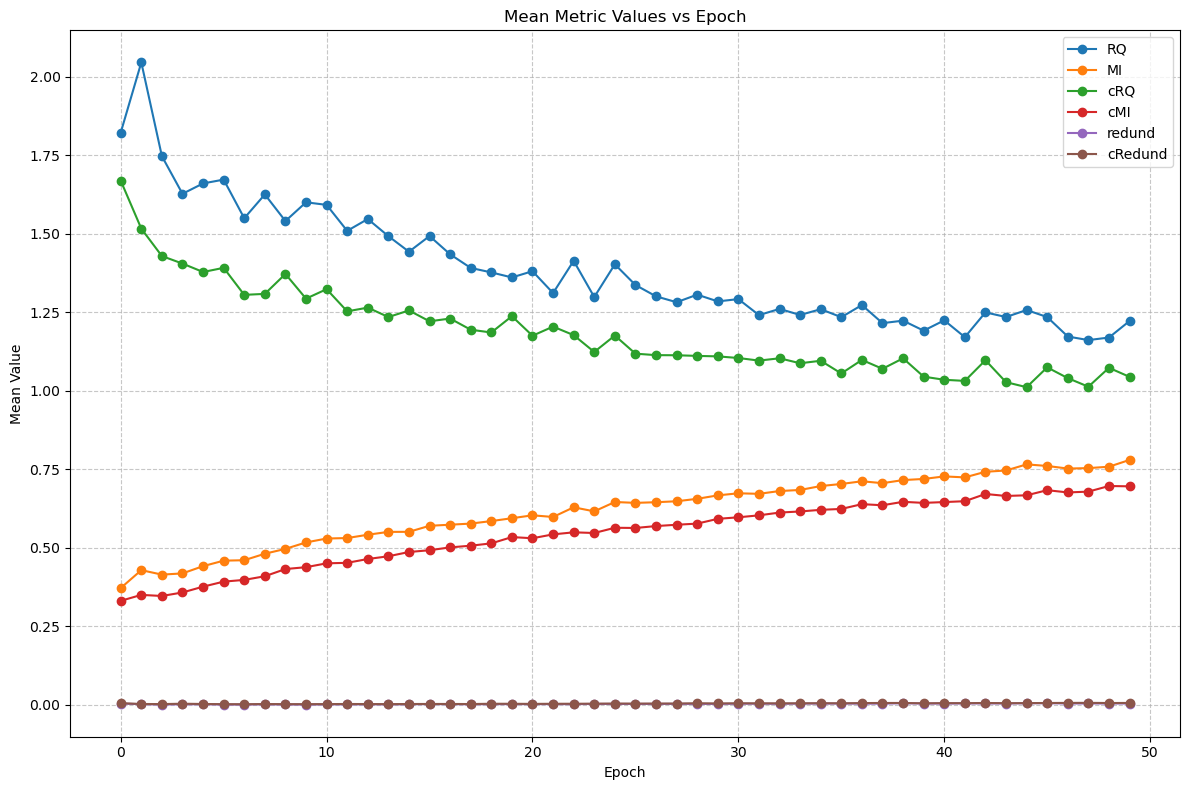

Available metrics: ['RQ', 'MI', 'redund', 'cRQ', 'cMI', 'cRedund']


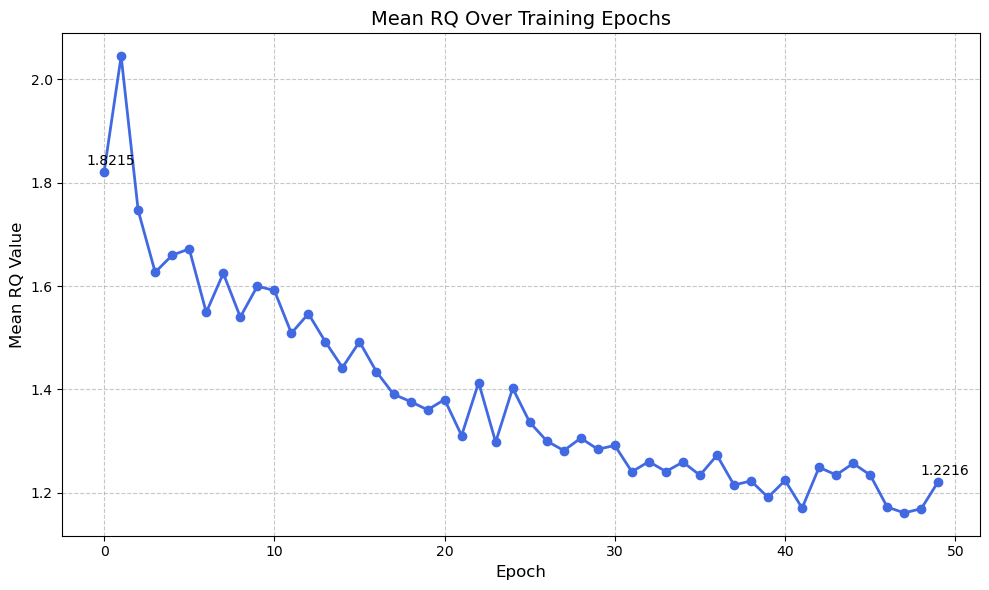

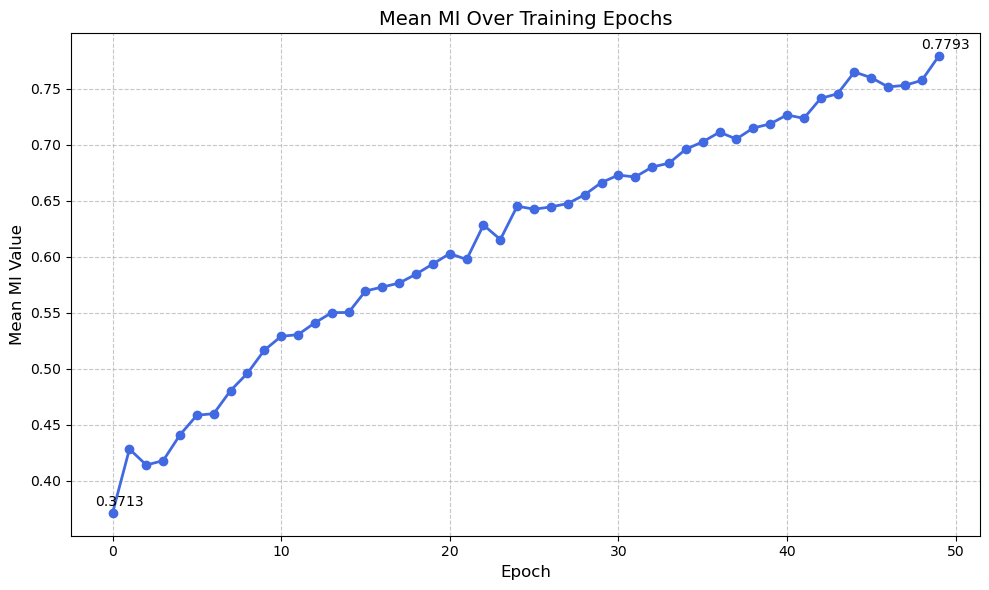

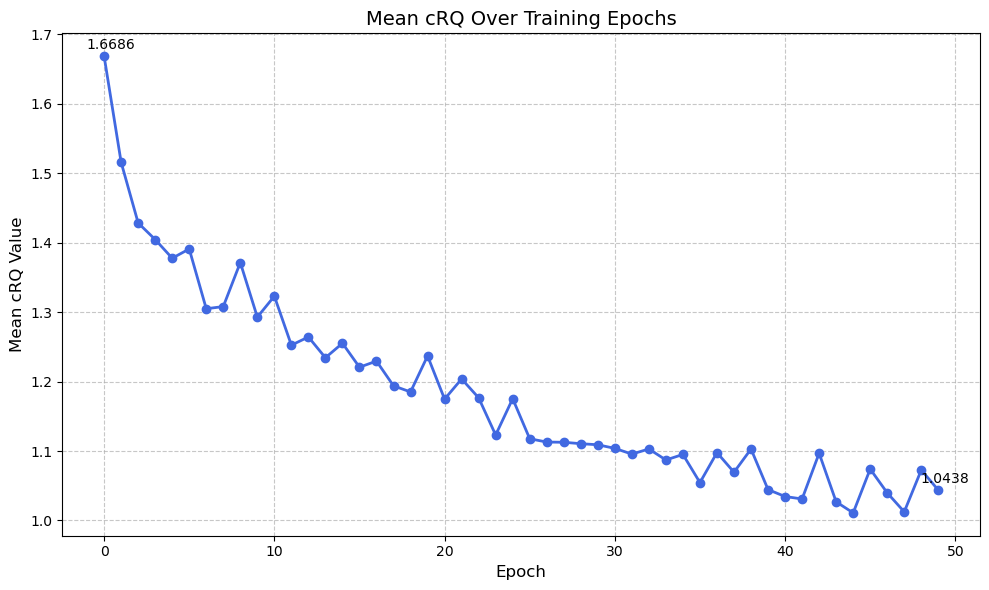

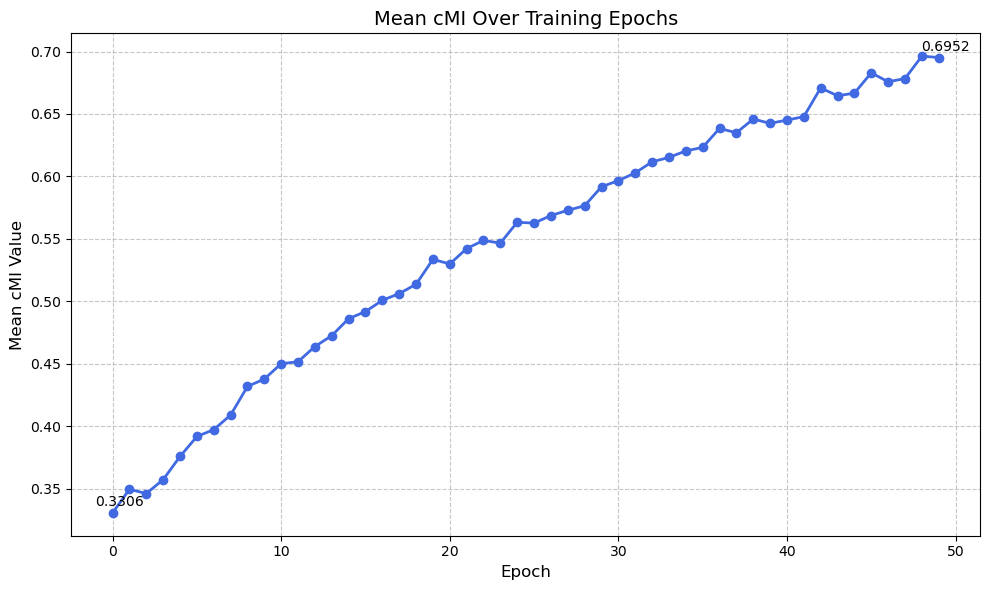

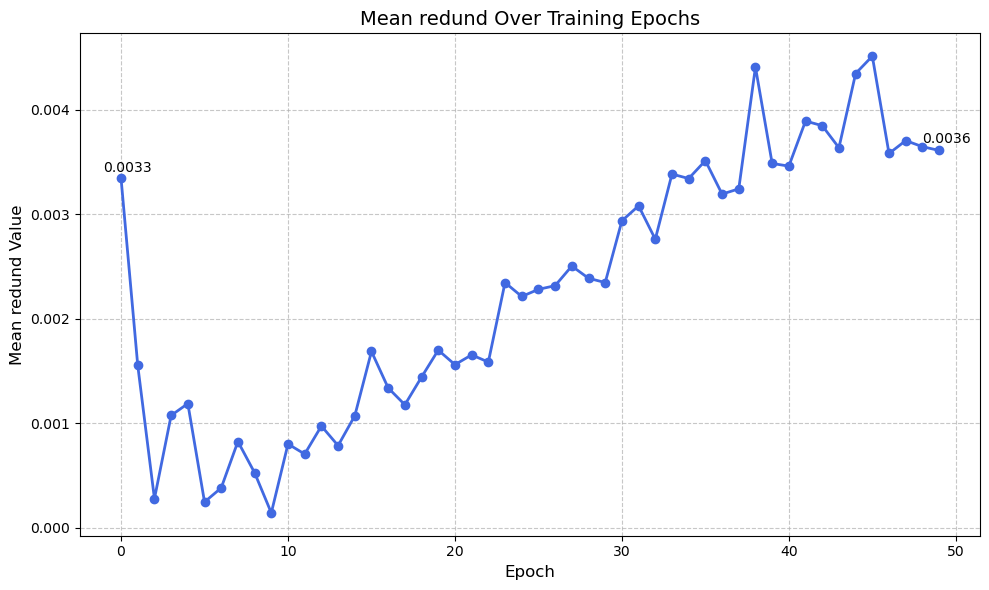

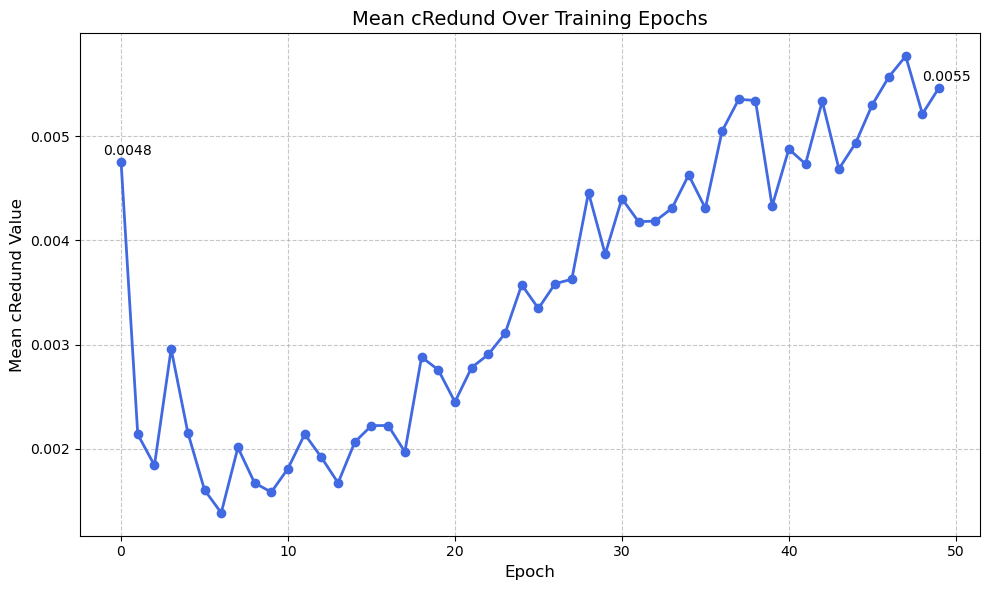

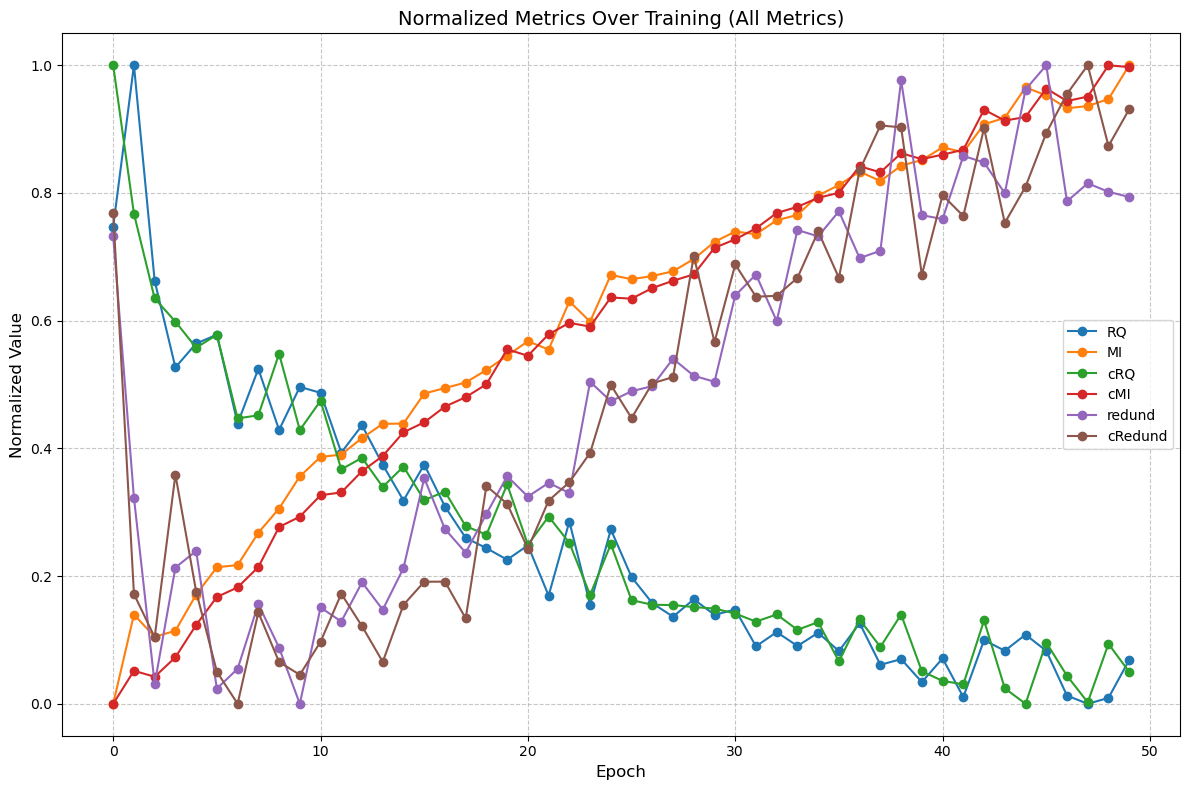

Available metrics: ['RQ', 'MI', 'redund', 'cRQ', 'cMI', 'cRedund']


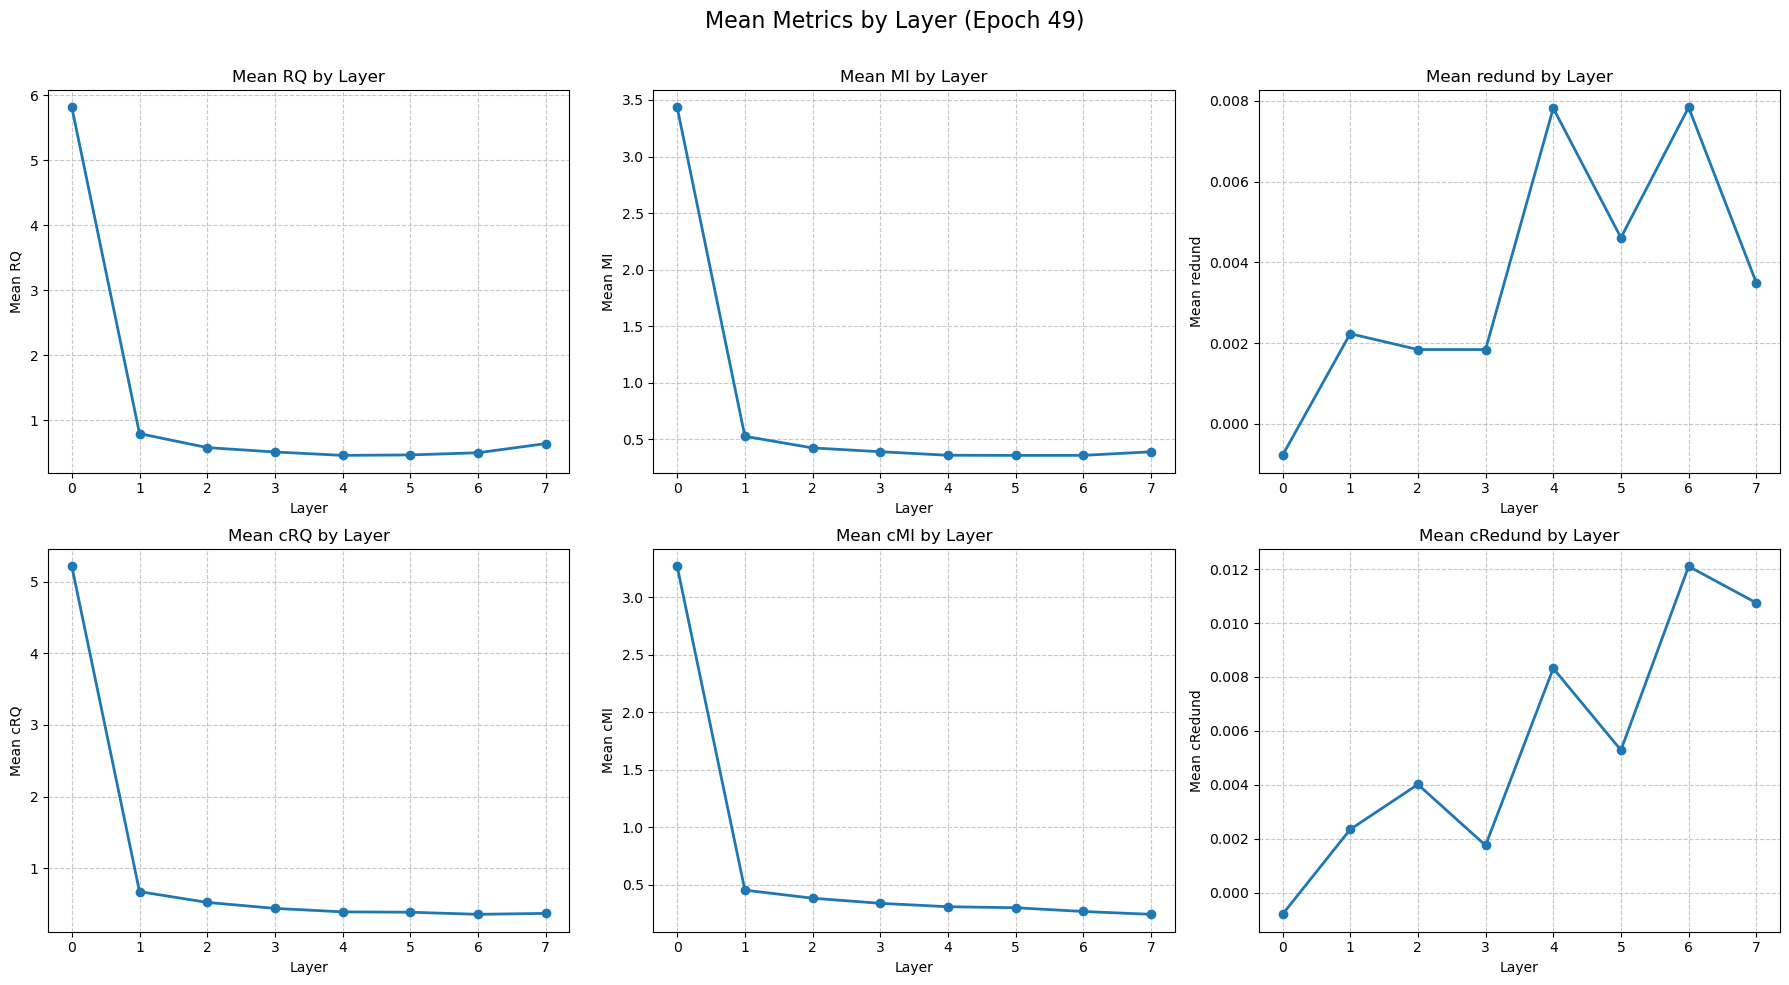

Available metrics: ['RQ', 'MI', 'redund', 'cRQ', 'cMI', 'cRedund']


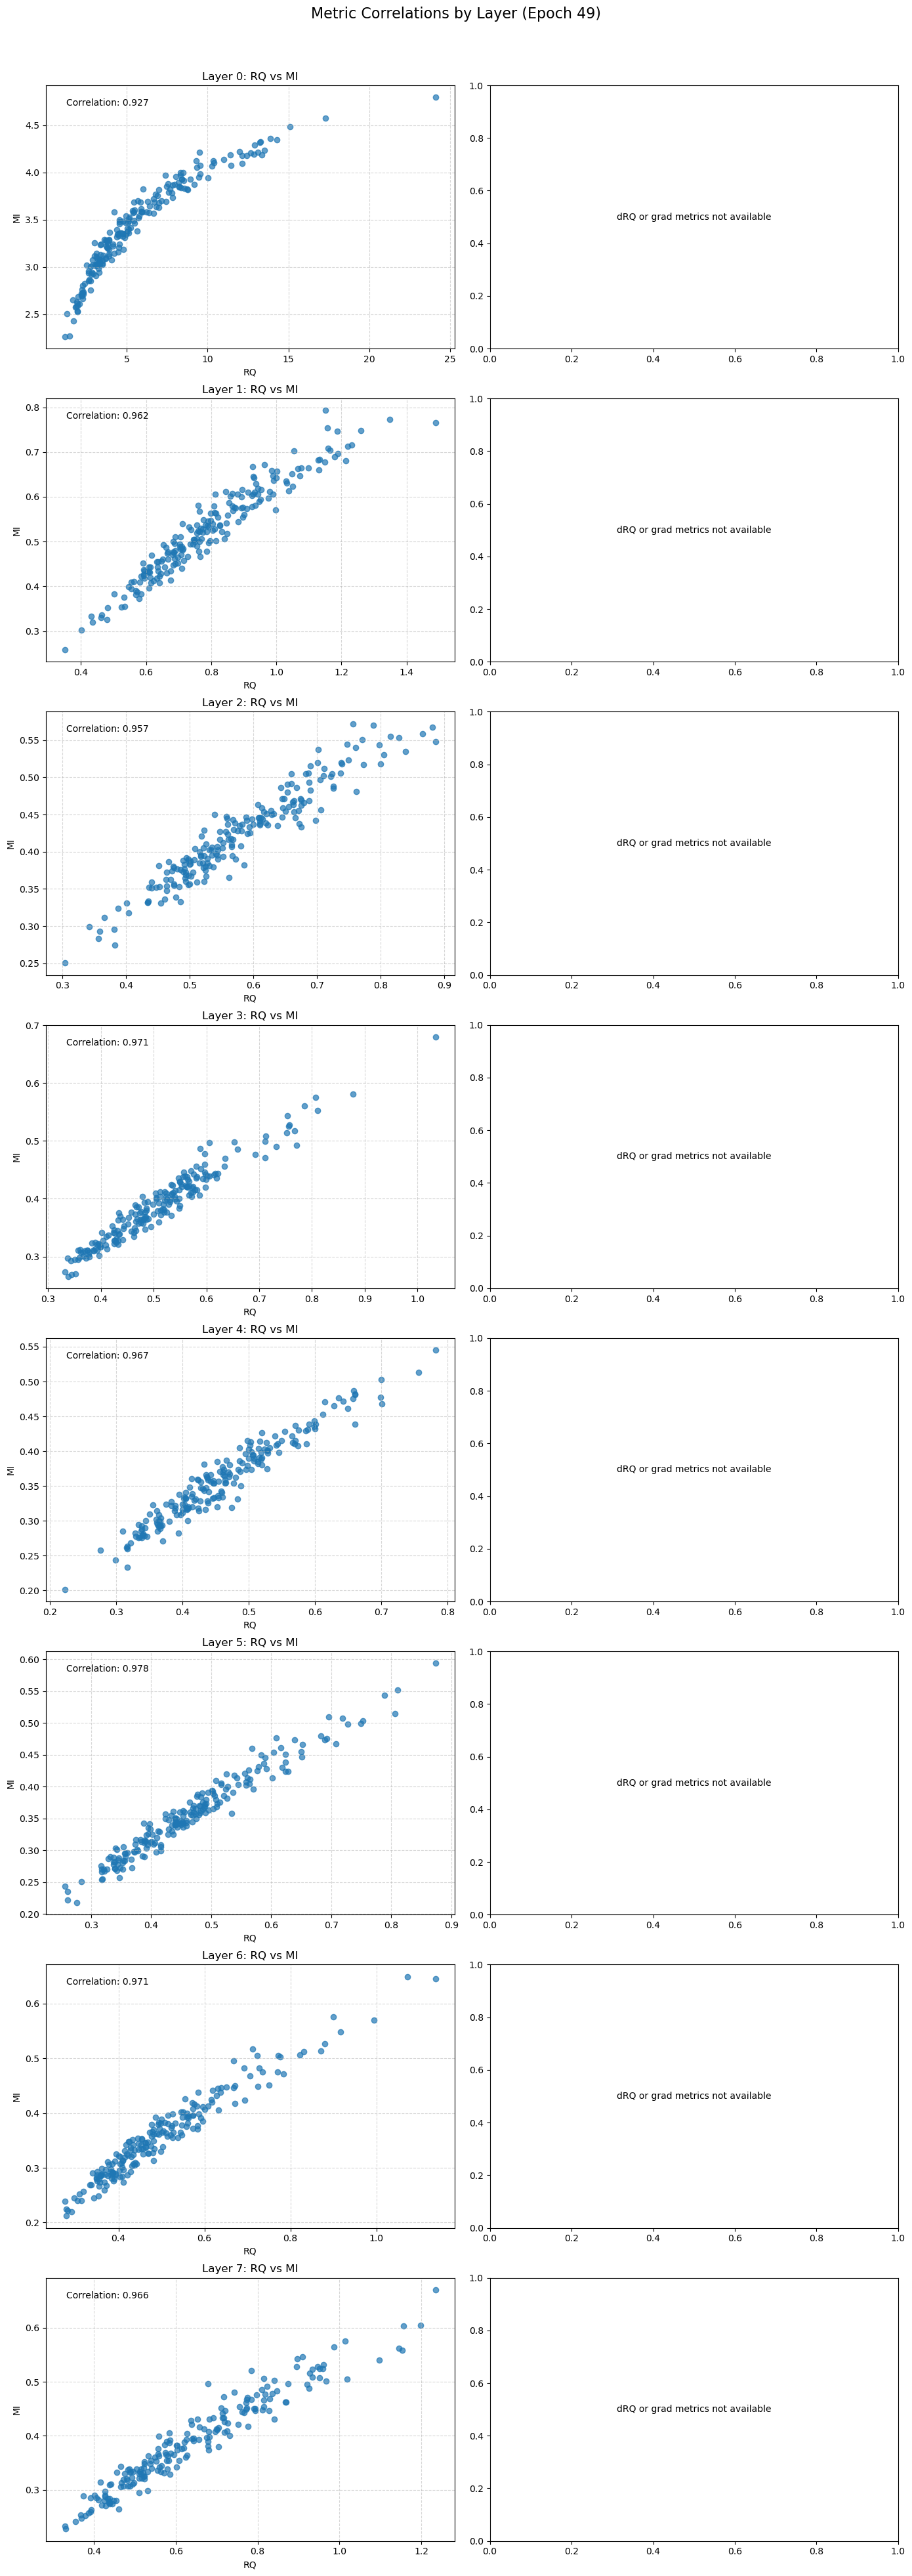

Unpruned final model test acc= 54.18%
Teacher model (unpruned) test acc= 54.18%


In [4]:
###############################################################################
# MAIN EXPERIMENT
###############################################################################
def main_experiment():
    # 1) Dataloaders
    train_loader, test_loader= get_cifar10_dataloaders(batch_size=1000)
    
    # 2) define an 8-layer MLP, hidden_dim=100, num_hidden_layers=5 
    #    (You can adjust these to hidden_dim=64 or 8 layers to your liking.)
    model= EightLayerMLP(input_dim=3*32*32, num_classes=10, hidden_dim=200, num_hidden_layers=8)
    
    # 3) train for e.g. 50 epochs, collecting unconditional + conditional metrics
    all_metrics= train_and_collect_all_metrics(model, train_loader, test_loader, num_epochs=50, device=device)
    
    # -- A) Plot mean metrics vs epoch, including redundancy:
    #    We'll pass the metric_list that includes 'redund' and 'cRedund'
    plot_mean_metrics_vs_epoch(all_metrics, metric_list=['RQ','MI','cRQ','cMI','redund','cRedund'])
    plot_individual_metrics_vs_epoch(all_metrics)
    plot_metrics_by_layer(all_metrics)
    
    plot_metric_correlations(all_metrics)
    # Evaluate final model
    test_acc= evaluate_accuracy(model, test_loader, device=device)
    print(f"Unpruned final model test acc= {test_acc:.2f}%")
    
    # -- B) We demonstrate pruning + distillation below. 
    #       We'll pick "cMI" as the metric. 
    def layer_metric_vals(all_metrics, epoch, metric_name='cMI'):
        """
        Gather [arr_of_shape(#neurons_layer1), arr_of_shape(#neurons_layer2), ...]
        for the chosen metric. If it's 'redund' or 'cRedund',
        we convert the redundancy matrix to per-neuron scores by row-average.
        """
        layer_vals= []
        for layer_idx in sorted(all_metrics[epoch].keys()):
            if metric_name in ['redund','cRedund']:
                mat= all_metrics[epoch][layer_idx][metric_name]
                n= mat.shape[0]
                arr= np.zeros(n)
                for i in range(n):
                    row= np.delete(mat[i], i)
                    arr[i]= np.mean(row) if len(row)>0 else 0
                layer_vals.append(arr)
            else:
                arr= all_metrics[epoch][layer_idx][metric_name]
                layer_vals.append(arr)
        return layer_vals
    
    last_epoch= max(all_metrics.keys())
    
    teacher_model= copy.deepcopy(model).to(device)
    base_acc= evaluate_accuracy(teacher_model, test_loader, device)
    print(f"Teacher model (unpruned) test acc= {base_acc:.2f}%")
    
    # We'll do a range of prune fractions, e.g. [0, 0.3, 0.5, 0.7, 0.9], etc.
    # but here we do 0.0 to 0.9 in increments.
    # fractions= [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    # metric_name_list= ['RQ','MI','cRQ','cMI','redund','cRedund']
    
    # results= {}
    # for mname in metric_name_list:
    #     prune_vals= layer_metric_vals(all_metrics, last_epoch, metric_name=mname)
    #     before_accs= []
    #     after_accs= []
    #     for frac in fractions:
    #         if frac<=0:
    #             # no prune
    #             pm= copy.deepcopy(model).to(device)
    #         else:
    #             pm= prune_nodes(model, prune_vals, fraction=frac, mode="lowest", device=device) 
    #             # or mode="highest" if you want to keep the smallest and remove the largest
    #         acc_b= evaluate_accuracy(pm, test_loader, device)
    #         # distill
    #         pm2= distill_student(teacher_model, pm, train_loader, device, alpha=0.5, T=1.0, epochs=1)
    #         acc_a= evaluate_accuracy(pm2, test_loader, device)
    #         before_accs.append(acc_b)
    #         after_accs.append(acc_a)
    #     results[mname]=(before_accs, after_accs)
    
    # # Summarize all metrics on the same figure
    # plt.figure(figsize=(10,6))
    # for mname in metric_name_list:
    #     baccs, aaccs= results[mname]
    #     plt.plot(fractions, baccs, '-o', label=f"{mname} before")
    #     plt.plot(fractions, aaccs, '--o', label=f"{mname} after")
    # plt.axhline(base_acc, color='k', ls='--', label="unpruned base")
    # plt.xlabel("Pruning fraction")
    # plt.ylabel("Accuracy (%)")
    # plt.title("Pruning vs Distillation for different metrics")
    # plt.legend()
    # plt.tight_layout()
    # plt.show()
    
    # # -- C) Plot final epoch metrics vs layer number:
    # #    We'll compute the MEAN across neurons (or row-averaged for redundancy).
    # print("\nPlot final epoch metrics vs layer index...\n")
    # final_vals= {}
    # for mname in metric_name_list:
    #     final_vals[mname]=[]
    # num_layers= len(all_metrics[last_epoch])
    # for lidx in range(num_layers):
    #     d= all_metrics[last_epoch][lidx]
    #     for mname in metric_name_list:
    #         if mname in ['redund','cRedund']:
    #             mat= d[mname]  # shape (#neurons,#neurons)
    #             n= mat.shape[0]
    #             if n>0:
    #                 rowavg= np.zeros(n)
    #                 for i in range(n):
    #                     row= np.delete(mat[i],i)
    #                     rowavg[i]= np.mean(row) if len(row)>0 else 0
    #                 final_vals[mname].append( np.mean(rowavg) )
    #             else:
    #                 final_vals[mname].append(0)
    #         else:
    #             arr= d[mname]  # shape (#neurons,)
    #             final_vals[mname].append( np.mean(arr) )
    
    # layers= np.arange(num_layers)
    # plt.figure(figsize=(9,6))
    # for mname in metric_name_list:
    #     plt.plot(layers, final_vals[mname], '-o', label=mname)
    # plt.title("Final epoch metric values vs layer index (mean across nodes)")
    # plt.xlabel("Layer index")
    # plt.ylabel("Mean Metric Value")
    # plt.legend()
    # plt.tight_layout()
    # plt.show()

if __name__=="__main__":
    main_experiment()

In [5]:
###############################################################################
# MAIN MODIFICATION: Train while also using some of these metrics in the loss
###############################################################################
def train_and_collect_all_metrics_new(
    model, 
    train_loader, 
    test_loader, 
    num_epochs=30, 
    device='cuda',
    alpha_rq=0.0,           # weighting for RQ (and similarly MI, cRQ, cMI if you want them)
    alpha_mi=0.0,
    alpha_c_rq=0.0,
    alpha_c_mi=0.0,
    alpha_redund=0.0,
    alpha_c_redund=0.0,
):
    """
    Train the model and collect both unconditional and conditional metrics at each epoch,
    but now includes an additional cost term from the chosen metrics.

    For demonstration:
      - We assume we want to MAXIMIZE RQ, MI, cRQ, cMI => cost -= alpha_rq * (sum RQ) etc.
      - We assume we want to MINIMIZE redund, cRedund => cost += alpha_redund * (sum redund).

    If you only want to use one or two, set others' alpha to 0.0.

    Returns:
    - all_metrics: dict[epoch -> layer_idx -> metrics]
    """
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3, verbose=True)
    criterion = nn.CrossEntropyLoss()
    
    # Create conditional covariance calculator
    cond_cov = ConditionalCovAverager(num_classes=10, subset_per_class=32)
    
    # Dictionary to store metrics
    all_metrics = {}
    
    for epoch in range(num_epochs):
        #######################################################################
        # Training phase with extra metric-based cost
        #######################################################################
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            # forward
            outputs = model(images)
            ce_loss = criterion(outputs, labels)
            
            # Now compute the additional metrics on this mini-batch. We do a simplified approach:
            #   We'll just pick one layer or sum across layers. 
            #   The original code collects layer-wise metrics AFTER training, 
            #   but for demonstration let's do e.g. "layer_idx=0" or sum across all layers.

            # We'll define an "extra_loss" that sums up a few metrics from all layers.
            #   Then we combine: total_loss = ce_loss + extra_loss (sign depending on max/min).
            batch_extra_loss = 0.0

            # Let's define which layers we measure the metrics on. 
            # Typically, you'd do it on each layer => sum up or average.
            # For demonstration, we do ALL layers:
            for layer_idx in range(model.num_layers()):
                # get layer weights
                W = model.layer_weights(layer_idx).detach()

                # estimate unconditional Cov of this layer input for this batch only 
                #   (rough approximation):
                cov_in, _ = estimate_layer_cov_batch(
                    model, images, layer_idx, device=device
                )
                RQ_vals, MI_vals = compute_unconditional_RQ_MI(W, cov_in)
                redund_mat       = compute_unconditional_redundancy(W, cov_in)
                
                # approximate "sum" or "mean" for each metric
                # you might choose sum, or mean, or something else
                sum_RQ      = float(torch.tensor(RQ_vals).sum().item())
                sum_MI      = float(torch.tensor(MI_vals).sum().item())
                sum_redund  = float(torch.tensor(redund_mat).sum().item())
                
                # For conditional versions, do a (very) rough approach with the batch 
                #   or skip unless we gather class-sorted samples
                # We'll do a placeholder that is 0.0 if we can't do it quickly here.
                sum_cRQ = 0.0
                sum_cMI = 0.0
                sum_cRedund = 0.0

                # accumulate
                # if we want to maximize RQ => cost -= alpha_rq * sum_RQ
                # if we want to minimize redund => cost += alpha_redund * sum_redund
                batch_extra_loss += (
                    - alpha_rq * sum_RQ
                    - alpha_mi * sum_MI
                    - alpha_c_rq * sum_cRQ
                    - alpha_c_mi * sum_cMI
                    + alpha_redund * sum_redund
                    + alpha_c_redund * sum_cRedund
                )

            # Combine into final loss
            #   ce_loss is a torch scalar, batch_extra_loss is a float => convert to torch
            extra_loss_tensor = ce_loss.new_tensor(batch_extra_loss)
            loss = ce_loss + extra_loss_tensor

            # backward + step
            loss.backward()
            optimizer.step()
            
            # track running stats
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_loss = running_loss / total
        train_acc = 100.0 * correct / total
        
        #######################################################################
        # Evaluation on test set
        #######################################################################
        model.eval()
        test_correct = 0
        test_total = 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()
        
        test_acc = 100.0 * test_correct / test_total
        
        print(f"[Epoch {epoch+1}/{num_epochs}] - TrainLoss={train_loss:.4f}, TrainAcc={train_acc:.2f}%, TestAcc={test_acc:.2f}%")
        
        # step scheduler
        scheduler.step(train_loss)

        #######################################################################
        # After epoch, collect unconditional + conditional metrics (full dataset).
        #######################################################################
        epoch_metrics = {}
        
        for layer_idx in range(model.num_layers()):
            W = model.layer_weights(layer_idx).detach().cpu()
            
            # unconditional
            cov_in, _ = estimate_layer_cov(model, train_loader, layer_idx, subset_size=256, device=device)
            RQ_vals, MI_vals = compute_unconditional_RQ_MI(W, cov_in)
            redund_mat = compute_unconditional_redundancy(W, cov_in)
            
            # conditional
            cond_cov_avg, class_covs, class_weights = cond_cov.collect_samples(
                model, train_loader, layer_idx, device=device
            )
            cRQ_vals, cMI_vals = compute_conditional_RQ_MI(W, class_covs, class_weights)
            cRedund_mat = compute_conditional_redundancy(W, class_covs, class_weights)
            
            epoch_metrics[layer_idx] = {
                'RQ':       RQ_vals,
                'MI':       MI_vals,
                'redund':   redund_mat,
                'cRQ':      cRQ_vals,
                'cMI':      cMI_vals,
                'cRedund':  cRedund_mat
            }
        
        all_metrics[epoch] = epoch_metrics
    
    return all_metrics

def estimate_layer_cov_batch(model, images, layer_idx, device='cuda'):
    """
    Very rough function: compute the covariance of the (layer_idx-1) activations
    from just 'images'. 
    """
    if layer_idx == 0:
        # then the input is just the images themselves
        x = images.view(images.size(0), -1)
    else:
        with torch.no_grad():
            act = get_activation(model, images, layer_idx-1)
        x = act
    x_centered = x - x.mean(dim=0, keepdim=True)
    cov = (x_centered.t() @ x_centered)/(x.size(0)-1)
    return cov, x.mean(dim=0, keepdim=True)

In [6]:
###############################################################################
# MAIN EXPERIMENT
###############################################################################
def main_experiment_rq():
    # 1) Dataloaders
    train_loader, test_loader= get_cifar10_dataloaders(batch_size=1000)
    
    # 2) define an 8-layer MLP, hidden_dim=100, num_hidden_layers=5 
    #    (You can adjust these to hidden_dim=64 or 8 layers to your liking.)
    model= EightLayerMLP(input_dim=3*32*32, num_classes=10, hidden_dim=200, num_hidden_layers=8)
    
    # 3) train for e.g. 50 epochs, collecting unconditional + conditional metrics
    all_metrics= train_and_collect_all_metrics_new(model, train_loader, test_loader, num_epochs=50, device=device,alpha_c_mi=0.0,)

    # -- A) Plot mean metrics vs epoch, including redundancy:
    #    We'll pass the metric_list that includes 'redund' and 'cRedund'
    plot_mean_metrics_vs_epoch(all_metrics, metric_list=['RQ','MI','cRQ','cMI','redund','cRedund'])
    plot_individual_metrics_vs_epoch(all_metrics)
    plot_metrics_by_layer(all_metrics)
    
    plot_metric_correlations(all_metrics)
    # Evaluate final model
    test_acc= evaluate_accuracy(model, test_loader, device=device)
    print(f"Unpruned final model test acc= {test_acc:.2f}%")
    
    # -- B) We demonstrate pruning + distillation below. 
    #       We'll pick "cMI" as the metric. 
    def layer_metric_vals(all_metrics, epoch, metric_name='cMI'):
        """
        Gather [arr_of_shape(#neurons_layer1), arr_of_shape(#neurons_layer2), ...]
        for the chosen metric. If it's 'redund' or 'cRedund',
        we convert the redundancy matrix to per-neuron scores by row-average.
        """
        layer_vals= []
        for layer_idx in sorted(all_metrics[epoch].keys()):
            if metric_name in ['redund','cRedund']:
                mat= all_metrics[epoch][layer_idx][metric_name]
                n= mat.shape[0]
                arr= np.zeros(n)
                for i in range(n):
                    row= np.delete(mat[i], i)
                    arr[i]= np.mean(row) if len(row)>0 else 0
                layer_vals.append(arr)
            else:
                arr= all_metrics[epoch][layer_idx][metric_name]
                layer_vals.append(arr)
        return layer_vals
    
    last_epoch= max(all_metrics.keys())
    
    teacher_model= copy.deepcopy(model).to(device)
    base_acc= evaluate_accuracy(teacher_model, test_loader, device)
    print(f"Teacher model (unpruned) test acc= {base_acc:.2f}%")
    



if __name__=="__main__":
    main_experiment_rq()

Files already downloaded and verified
Files already downloaded and verified
[Epoch 1/50] - TrainLoss=1.8064, TrainAcc=34.60%, TestAcc=42.21%


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cpu and cuda:0! (when checking argument for argument mat2 in method wrapper_CUDA_mm)

In [ ]:
###############################################################################
# MAIN EXPERIMENT
###############################################################################
def main_experiment_rq():
    # 1) Dataloaders
    train_loader, test_loader= get_cifar10_dataloaders(batch_size=1000)
    
    # 2) define an 8-layer MLP, hidden_dim=100, num_hidden_layers=5 
    #    (You can adjust these to hidden_dim=64 or 8 layers to your liking.)
    model= EightLayerMLP(input_dim=3*32*32, num_classes=10, hidden_dim=200, num_hidden_layers=8)
    
    # 3) train for e.g. 50 epochs, collecting unconditional + conditional metrics
    all_metrics= train_and_collect_all_metrics_new(model, train_loader, test_loader, num_epochs=50, device=device,alpha_mi=0.0,)

    # -- A) Plot mean metrics vs epoch, including redundancy:
    #    We'll pass the metric_list that includes 'redund' and 'cRedund'
    plot_mean_metrics_vs_epoch(all_metrics, metric_list=['RQ','MI','cRQ','cMI','redund','cRedund'])
    plot_individual_metrics_vs_epoch(all_metrics)
    plot_metrics_by_layer(all_metrics)
    
    plot_metric_correlations(all_metrics)
    # Evaluate final model
    test_acc= evaluate_accuracy(model, test_loader, device=device)
    print(f"Unpruned final model test acc= {test_acc:.2f}%")
    
    # -- B) We demonstrate pruning + distillation below. 
    #       We'll pick "cMI" as the metric. 
    def layer_metric_vals(all_metrics, epoch, metric_name='cMI'):
        """
        Gather [arr_of_shape(#neurons_layer1), arr_of_shape(#neurons_layer2), ...]
        for the chosen metric. If it's 'redund' or 'cRedund',
        we convert the redundancy matrix to per-neuron scores by row-average.
        """
        layer_vals= []
        for layer_idx in sorted(all_metrics[epoch].keys()):
            if metric_name in ['redund','cRedund']:
                mat= all_metrics[epoch][layer_idx][metric_name]
                n= mat.shape[0]
                arr= np.zeros(n)
                for i in range(n):
                    row= np.delete(mat[i], i)
                    arr[i]= np.mean(row) if len(row)>0 else 0
                layer_vals.append(arr)
            else:
                arr= all_metrics[epoch][layer_idx][metric_name]
                layer_vals.append(arr)
        return layer_vals
    
    last_epoch= max(all_metrics.keys())
    
    teacher_model= copy.deepcopy(model).to(device)
    base_acc= evaluate_accuracy(teacher_model, test_loader, device)
    print(f"Teacher model (unpruned) test acc= {base_acc:.2f}%")
    



if __name__=="__main__":
    main_experiment_rq()